In [1]:
from prophet import Prophet
import pandas as pd
import numpy as np
from sklearn.metrics import mean_squared_error
df= pd.read_csv('AirPassengers.csv')

/Users/vivitsaupretimac/Desktop/MML/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Importing plotly failed. Interactive plots will not work.


In [2]:
df= df.rename(columns={'#Passengers':'y', 'Month':'ds'})

In [3]:

df.head(5)

,ds,y
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
df['y_orig']= df['y']
print(df.head(5))

        ds    y  y_orig
0  1949-01  112     112
1  1949-02  118     118
2  1949-03  132     132
3  1949-04  129     129
4  1949-05  121     121


In [5]:
df['y']= np.log(df['y'])

In [6]:
df.head(5)

,ds,y,y_orig
0,1949-01,4.718499,112
1,1949-02,4.770685,118
2,1949-03,4.882802,132
3,1949-04,4.859812,129
4,1949-05,4.795791,121


In [10]:
model= Prophet()
model.fit(df)

11:05:25 - cmdstanpy - INFO - Chain [1] start processing
11:05:27 - cmdstanpy - INFO - Chain [1] done processing


In [13]:
future_data = model.make_future_dataframe(periods=12, freq='ME')

In [17]:
forecast_data= model.predict(future_data)
forecast_data.tail(5)

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
151,1961-07-31,6.273406,6.436217,6.530449,6.262743,6.287604,0.211916,0.211916,0.211916,0.211916,0.211916,0.211916,0.0,0.0,0.0,6.485322
152,1961-08-31,6.282581,6.317853,6.414966,6.269537,6.300179,0.081887,0.081887,0.081887,0.081887,0.081887,0.081887,0.0,0.0,0.0,6.364469
153,1961-09-30,6.291460,6.160845,6.257459,6.275441,6.312900,-0.084906,-0.084906,-0.084906,-0.084906,-0.084906,-0.084906,0.0,0.0,0.0,6.206555
154,1961-10-31,6.300635,6.020700,6.124012,6.280900,6.325157,-0.228290,-0.228290,-0.228290,-0.228290,-0.228290,-0.228290,0.0,0.0,0.0,6.072345
155,1961-11-30,6.309514,6.165990,6.271176,6.288016,6.338358,-0.095729,-0.095729,-0.095729,-0.095729,-0.095729,-0.095729,0.0,0.0,0.0,6.213785


In [19]:
forecast_data[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail(5)

,ds,yhat,yhat_lower,yhat_upper
151,1961-07-31,6.485322,6.436217,6.530449
152,1961-08-31,6.364469,6.317853,6.414966
153,1961-09-30,6.206555,6.160845,6.257459
154,1961-10-31,6.072345,6.020700,6.124012
155,1961-11-30,6.213785,6.165990,6.271176


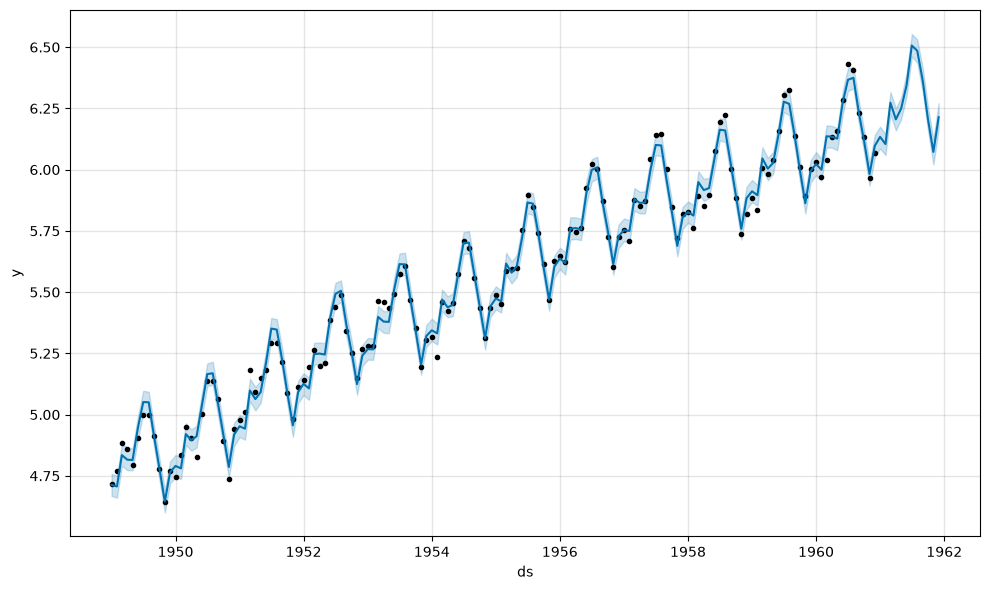

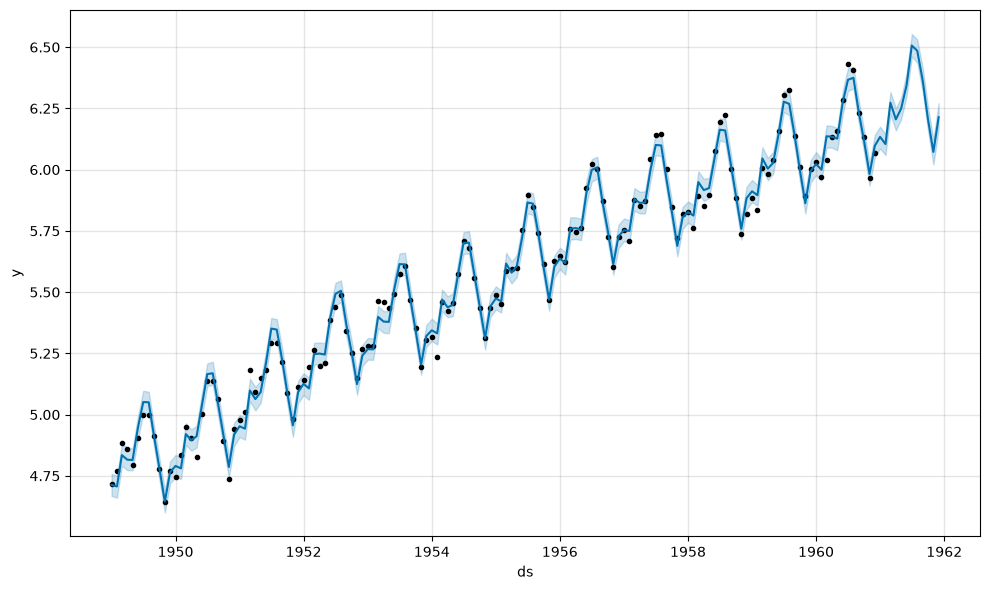

In [21]:
model.plot(forecast_data)

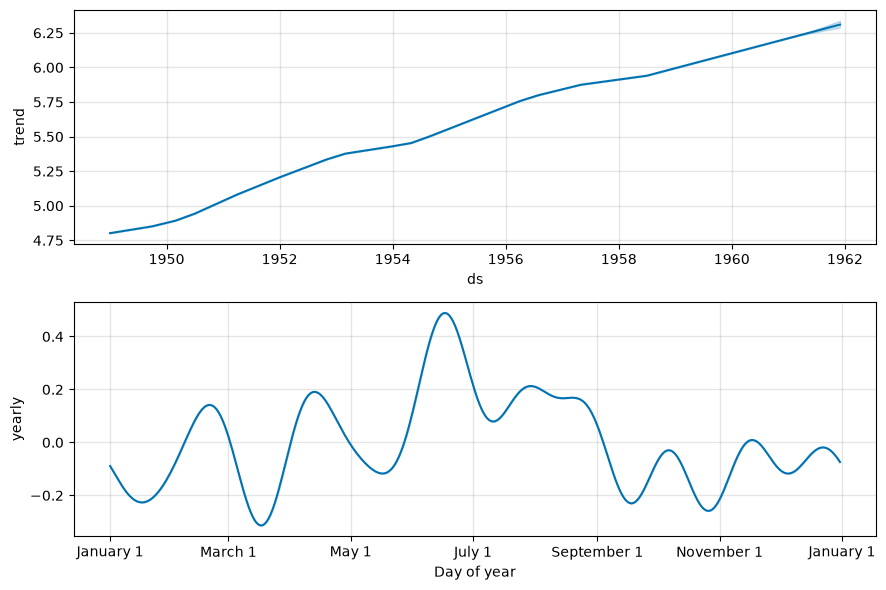

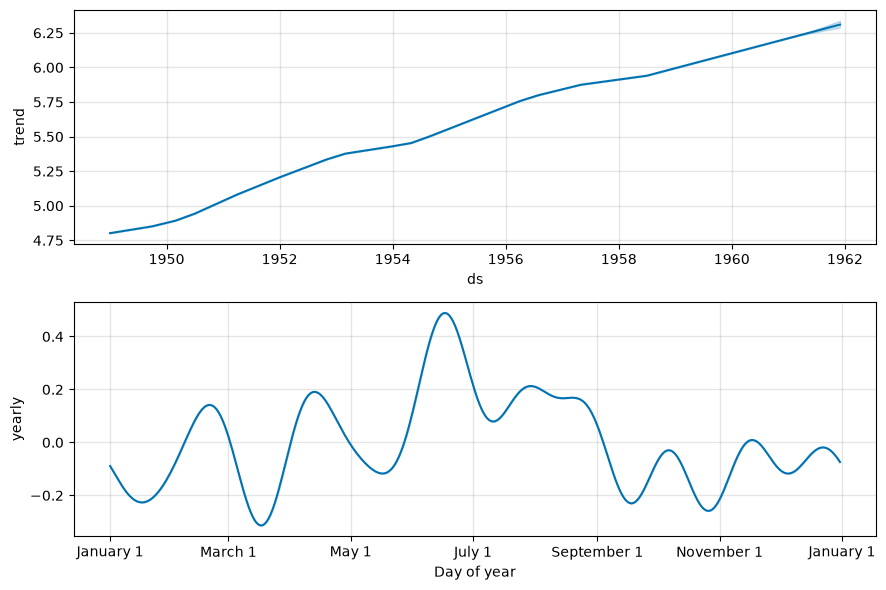

In [22]:
model.plot_components(forecast_data)

In [24]:
forecast_data_orig['yhat'] = np.exp(forecast_data_orig['yhat'])
forecast_data_orig['yhat_lower'] = np.exp(forecast_data_orig['yhat_lower'])
forecast_data_orig['yhat_upper'] = np.exp(forecast_data_orig['yhat_upper'])

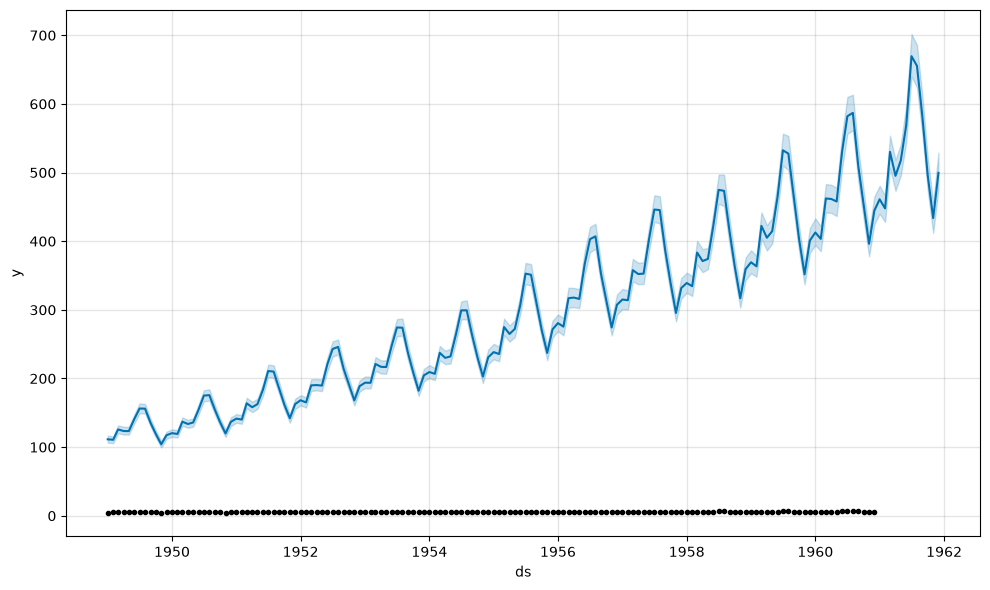

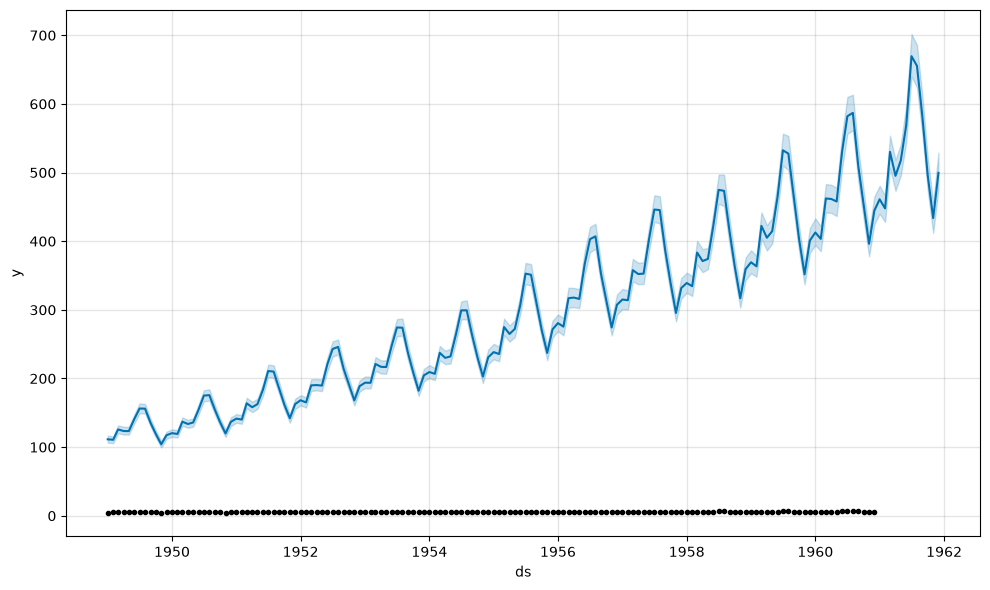

In [27]:
model.plot(forecast_data_orig)

In [30]:
df['y_log']= df['y']
df['y']= df['y_orig']

In [31]:
final_df= pd.DataFrame(forecast_data_orig)

In [35]:
import plotly.graph_objs as go
import plotly.offline as py


actual_chart = go.Scatter(
    y=df['y_orig'],
    name='Actual'
)

predict_chart = go.Scatter(
    y=final_df['yhat'],
    name='Predicted'
)

predict_chart_upper = go.Scatter(
    y=final_df['yhat_upper'],
    name='Predicted Upper'
)

predict_chart_lower = go.Scatter(
    y=final_df['yhat_lower'],
    name='Predicted Lower'
)

py.plot(
    [actual_chart, predict_chart, predict_chart_upper, predict_chart_lower],
    image_width=400,
    image_height=400
)

'temp-plot.html'